# Gibbs Sampling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from gibbs_sampling import GibbsGaussianMixture
from gibbs_plots import *

%load_ext autoreload
%autoreload 2

In [3]:
FONTSIZE=16
LABELSIZE=0.9*FONTSIZE
LINEWIDTH=2.0
FIGWIDTH=8
ASPECT_RATIO=4/3

plt.rcParams['axes.labelsize'] = FONTSIZE
plt.rcParams['axes.linewidth'] = LINEWIDTH
plt.rcParams['axes.titlesize'] = 1.1*FONTSIZE
plt.rcParams['figure.figsize'] = [FIGWIDTH, FIGWIDTH/ASPECT_RATIO]
plt.rcParams['figure.labelsize'] = FONTSIZE
plt.rcParams['figure.titlesize'] = 1.1*FONTSIZE
plt.rcParams['legend.fancybox'] = False
plt.rcParams['legend.framealpha'] = 1.0
plt.rcParams['legend.fontsize'] = LABELSIZE
plt.rcParams['legend.title_fontsize'] = LABELSIZE
plt.rcParams['patch.linewidth'] = LINEWIDTH
plt.rcParams['lines.linewidth'] = LINEWIDTH
plt.rcParams['xtick.labelsize'] = LABELSIZE
plt.rcParams['ytick.labelsize'] = LABELSIZE
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['figure.autolayout'] = True

plt.rcParams['patch.edgecolor'] = 'black'

In [4]:
DATA_PATH = "../GRBs/GRB_data.txt"
arr = np.loadtxt(DATA_PATH, skiprows=1)
logT90 = arr[:,0]
sigma_logT90 = arr[:,1]

## num_cluster = 2

In [9]:
gm = GibbsGaussianMixture(data=logT90, num_clusters=2, alpha=1.0, rng_seed=1234)

<Axes: >

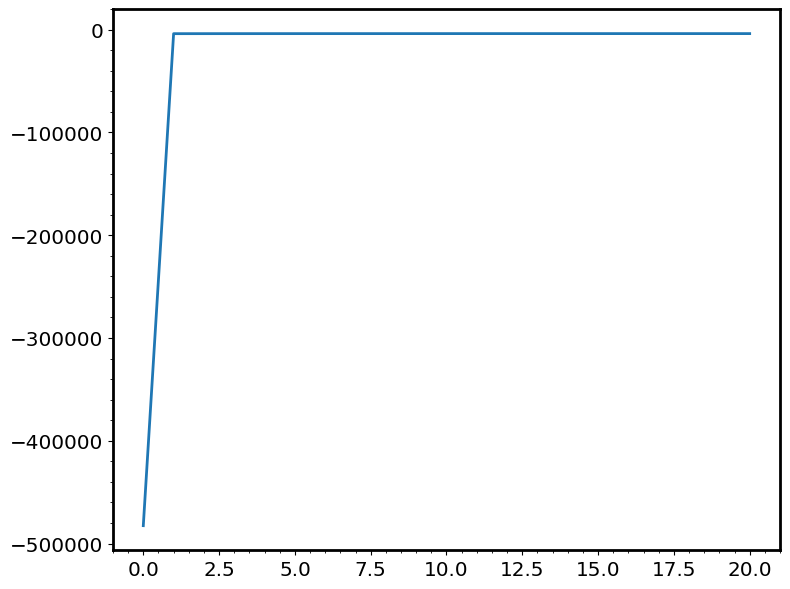

In [15]:
# track log-likelihood for 20 Gibbs steps
ll = [gm.log_likelihood()]
for _ in range(20):
    gm.gibbs_step()
    ll.append(gm.log_likelihood())

# plot using pandas for convenience
pd.Series(ll).plot()

In [10]:
%%time 
# con iter = 5000: 47min 14s
LOAD = True

if LOAD==0:
    # sample_trace: save means, sigmas and pi for 100 iterations
    samples = gm.sample_trace(n_iters=5000, burnin=0, thin=1)
    np.savetxt('../chains/chain_gibbs.txt',samples)
else:
    samples = np.loadtxt('../chains/chain_gibbs.txt')
print('samples shape (d,N):', samples.shape)
# d = 3 * K, N = number of saved iterations

samples shape (d,N): (6, 5000)
CPU times: user 12.4 ms, sys: 196 µs, total: 12.6 ms
Wall time: 11.9 ms


In [11]:
K = gm.num_clusters_
names = [f"$\mu_{i+1}$" for i in range(K)] + [f"$\sigma_{i+1}$" for i in range(K)] + [f"$w_{i+1}$" for i in range(K)]
# true_vals presi dalla mediana di mcmc reale con sigma_logT90=0
true_vals = [-0.204, 3.75-0.204, 1.41, 0.991, 0.318, 1-0.318]

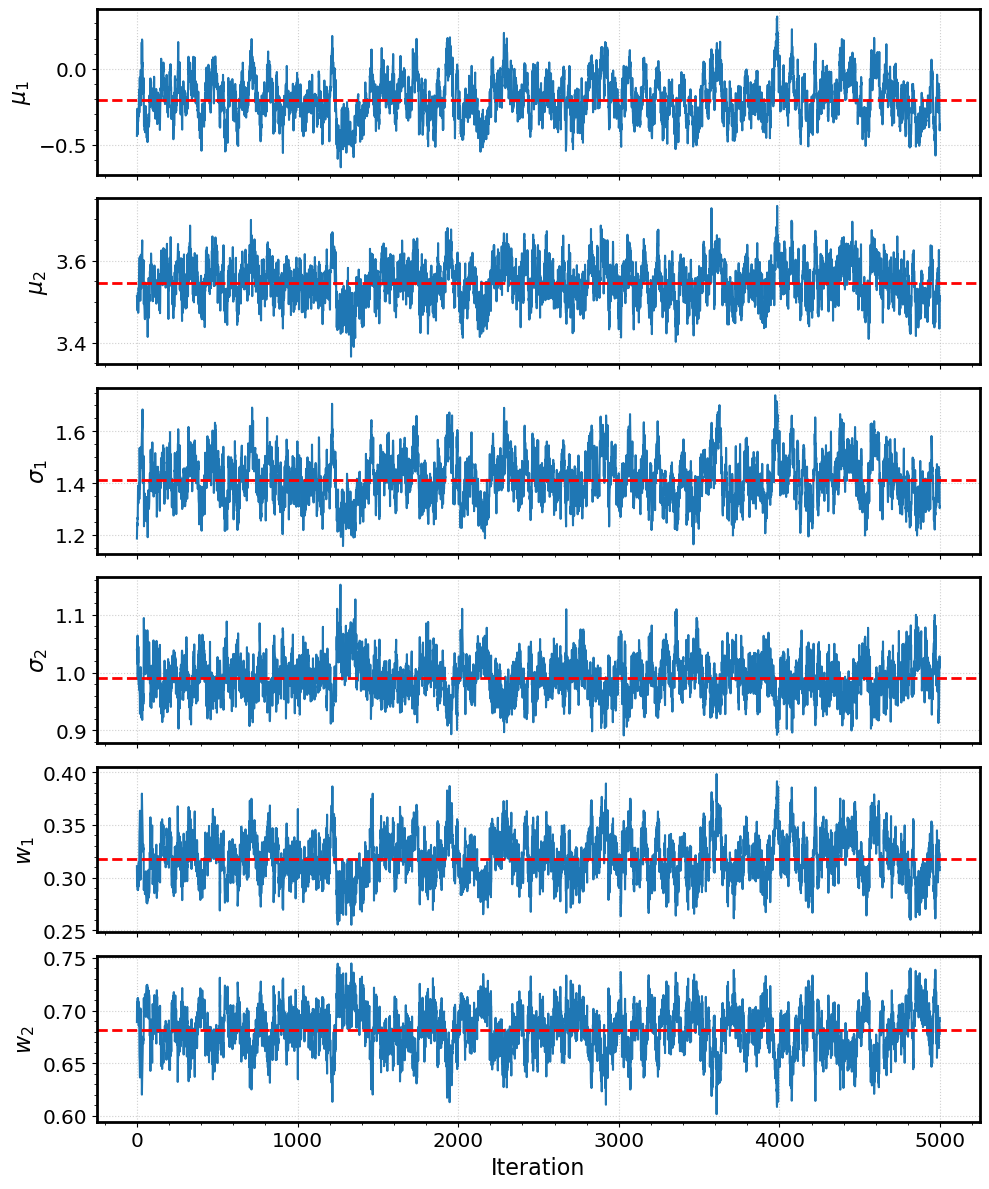

In [59]:
fig_trace, _ = trace_plot(samples, param_names=names, true_values=true_vals)

In [12]:
burnin = 10
samples_new = samples[:, burnin:]
samples_new.shape

(6, 4990)

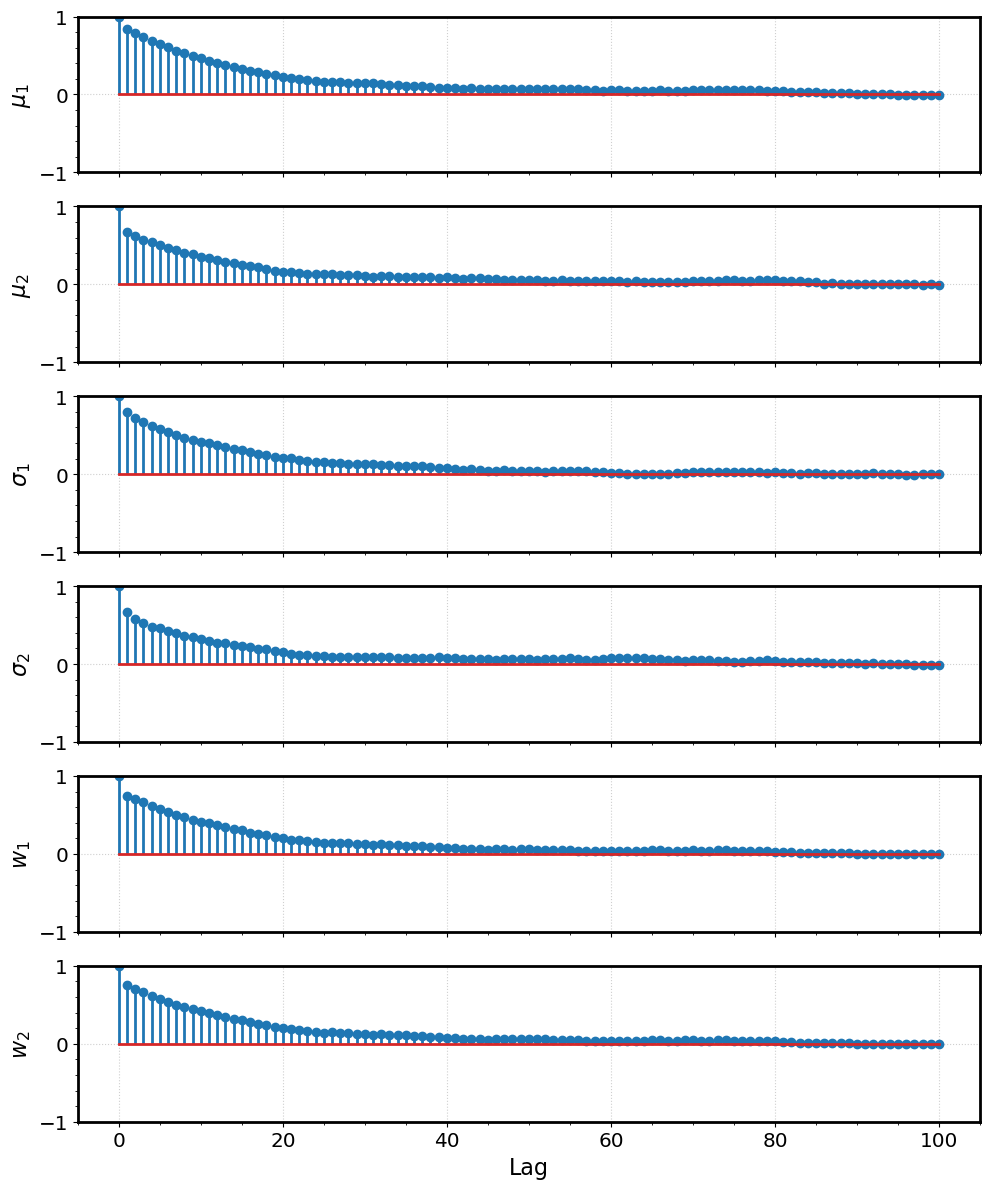

In [62]:
fig_acf, _ = autocorr_plot(samples_new, param_names=names, nlags=100)

In [48]:
thinning = 25
samples_new = samples_new[:, ::thinning]
samples_new.shape

(6, 200)

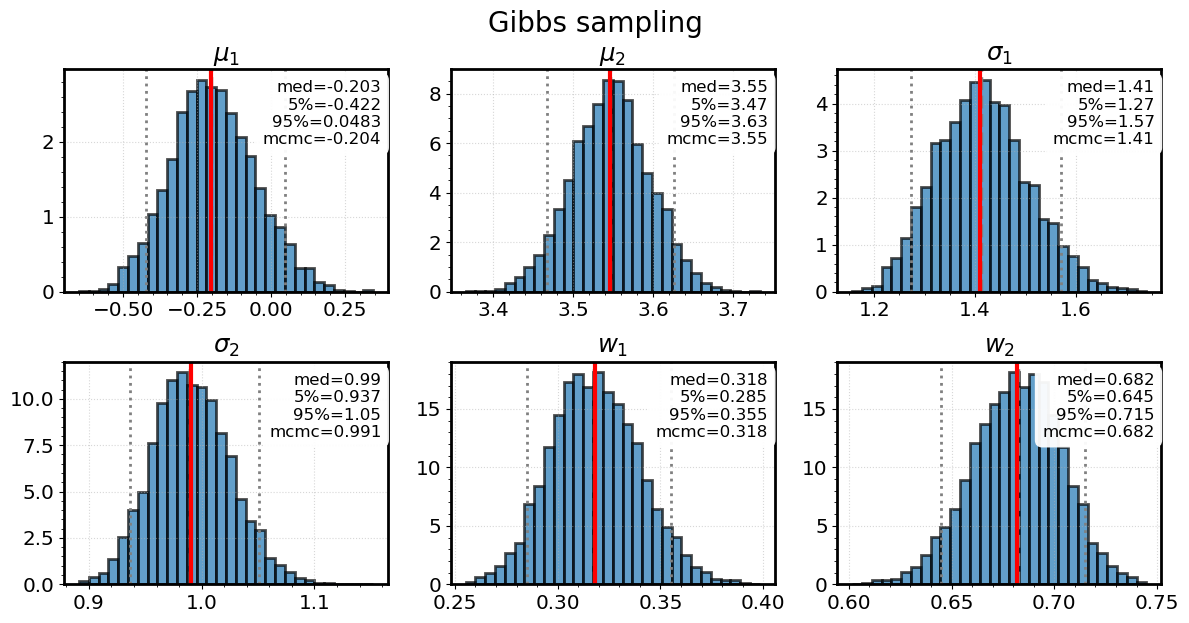

In [13]:
fig, axes = marginal_plots(samples_new, param_names=names, bins=30, true_values=true_vals)
plt.savefig('../figure/gibbs_sampling/gibbs_sampling.png', dpi=300, bbox_inches='tight')
plt.savefig('../figure/gibbs_sampling/gibbs_sampling.pdf', dpi=300, bbox_inches='tight')
plt.show()

## num_cluster = 3

<Axes: >

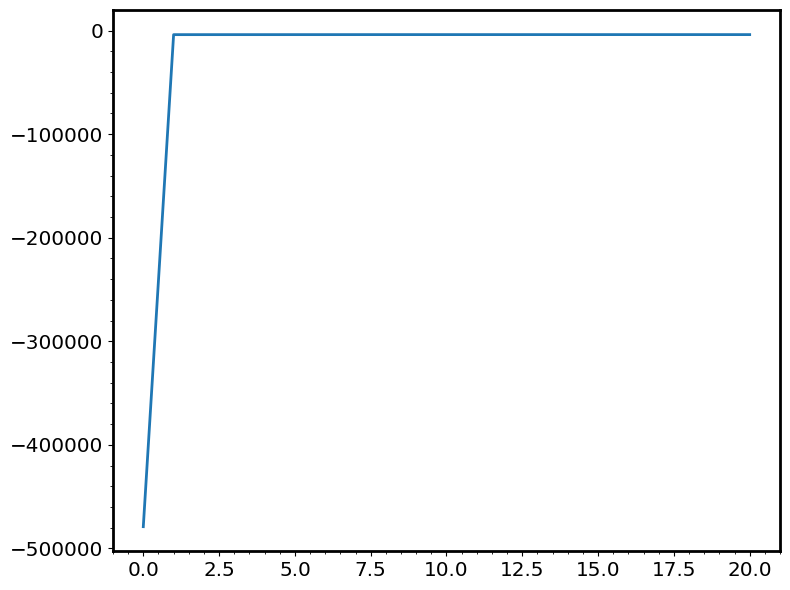

In [5]:
gm = GibbsGaussianMixture(data=logT90, num_clusters=3, alpha=1.0, rng_seed=1234)

# track log-likelihood for 20 Gibbs steps
ll = [gm.log_likelihood()]
for _ in range(20):
    gm.gibbs_step()
    ll.append(gm.log_likelihood())

# plot using pandas for convenience
pd.Series(ll).plot()

In [37]:
%%time 
#  1h 14min 32s
LOAD = True

if LOAD==0:
    # sample_trace: save means, sigmas and pi for 100 iterations
    samples = gm.sample_trace(n_iters=5000, burnin=0, thin=1)
    np.savetxt('../chains/chain_gibbs_clusters=3.txt',samples)
else:
    samples = np.loadtxt('../chains/gibbs_sampling/chain_gibbs_clusters=3.txt')
print('samples shape (d,N):', samples.shape)
# d = 3 * K, N = number of saved iterations

samples shape (d,N): (9, 5000)
CPU times: user 25.2 ms, sys: 4 ms, total: 29.2 ms
Wall time: 27 ms


In [9]:
K = gm.num_clusters_
names = [f"$\mu_{i+1}$" for i in range(K)] + [f"$\sigma_{i+1}$" for i in range(K)] + [f"$w_{i+1}$" for i in range(K)]
# true_vals presi dalla mediana e media di nested sample multi 
# i seguenti valori sono stati trovati con sigma_logT90 diverso da 0, 
# mentre il gibbs sampling è calcolato con sigma_logT90=0, il confronto non è corretto
true_vals_mean   = [-0.599, 2.22, 3.72, 1.16, 1.18, 0.872, 0.236, 0.262, 0.502]
true_vals_median = [-0.578, 2.22, 3.69, 1.16, 1.20, 0.900, 0.247, 0.239, 0.555]

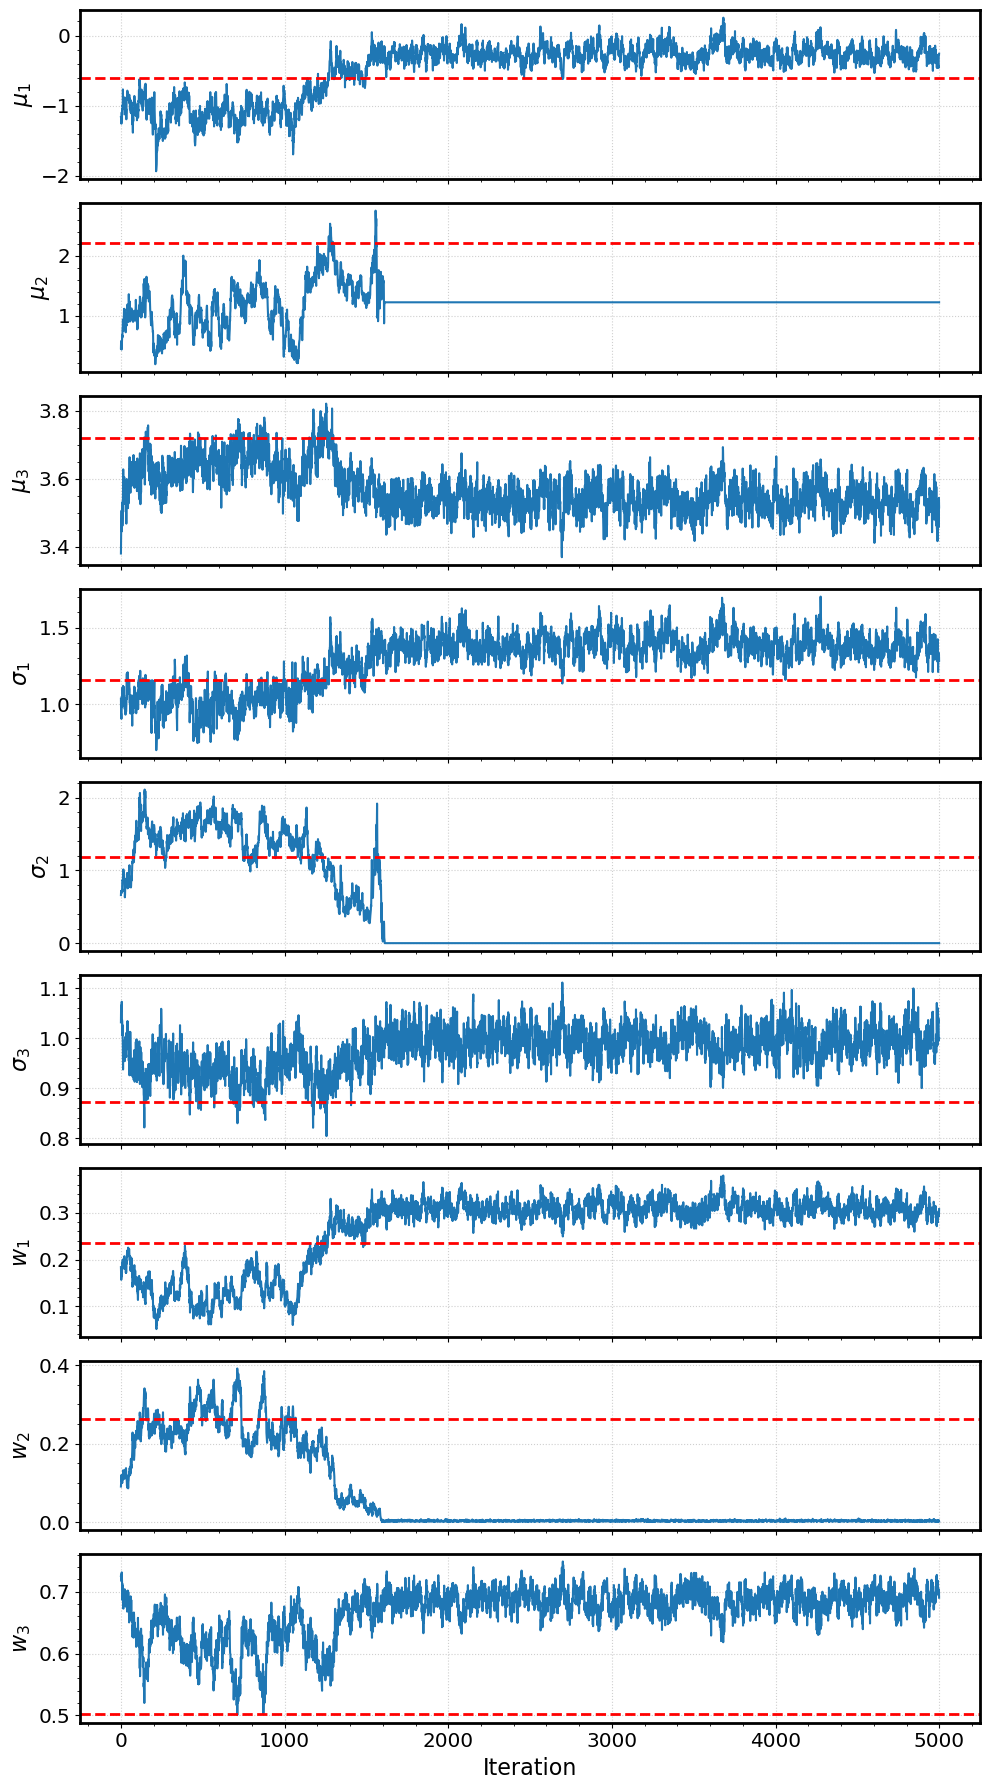

In [10]:
fig_trace, _ = trace_plot(samples, param_names=names, true_values=true_vals_mean)

In [19]:
burnin = 1600
samples_new = samples[:, burnin:]

In [20]:
samples_new.shape

(9, 3400)

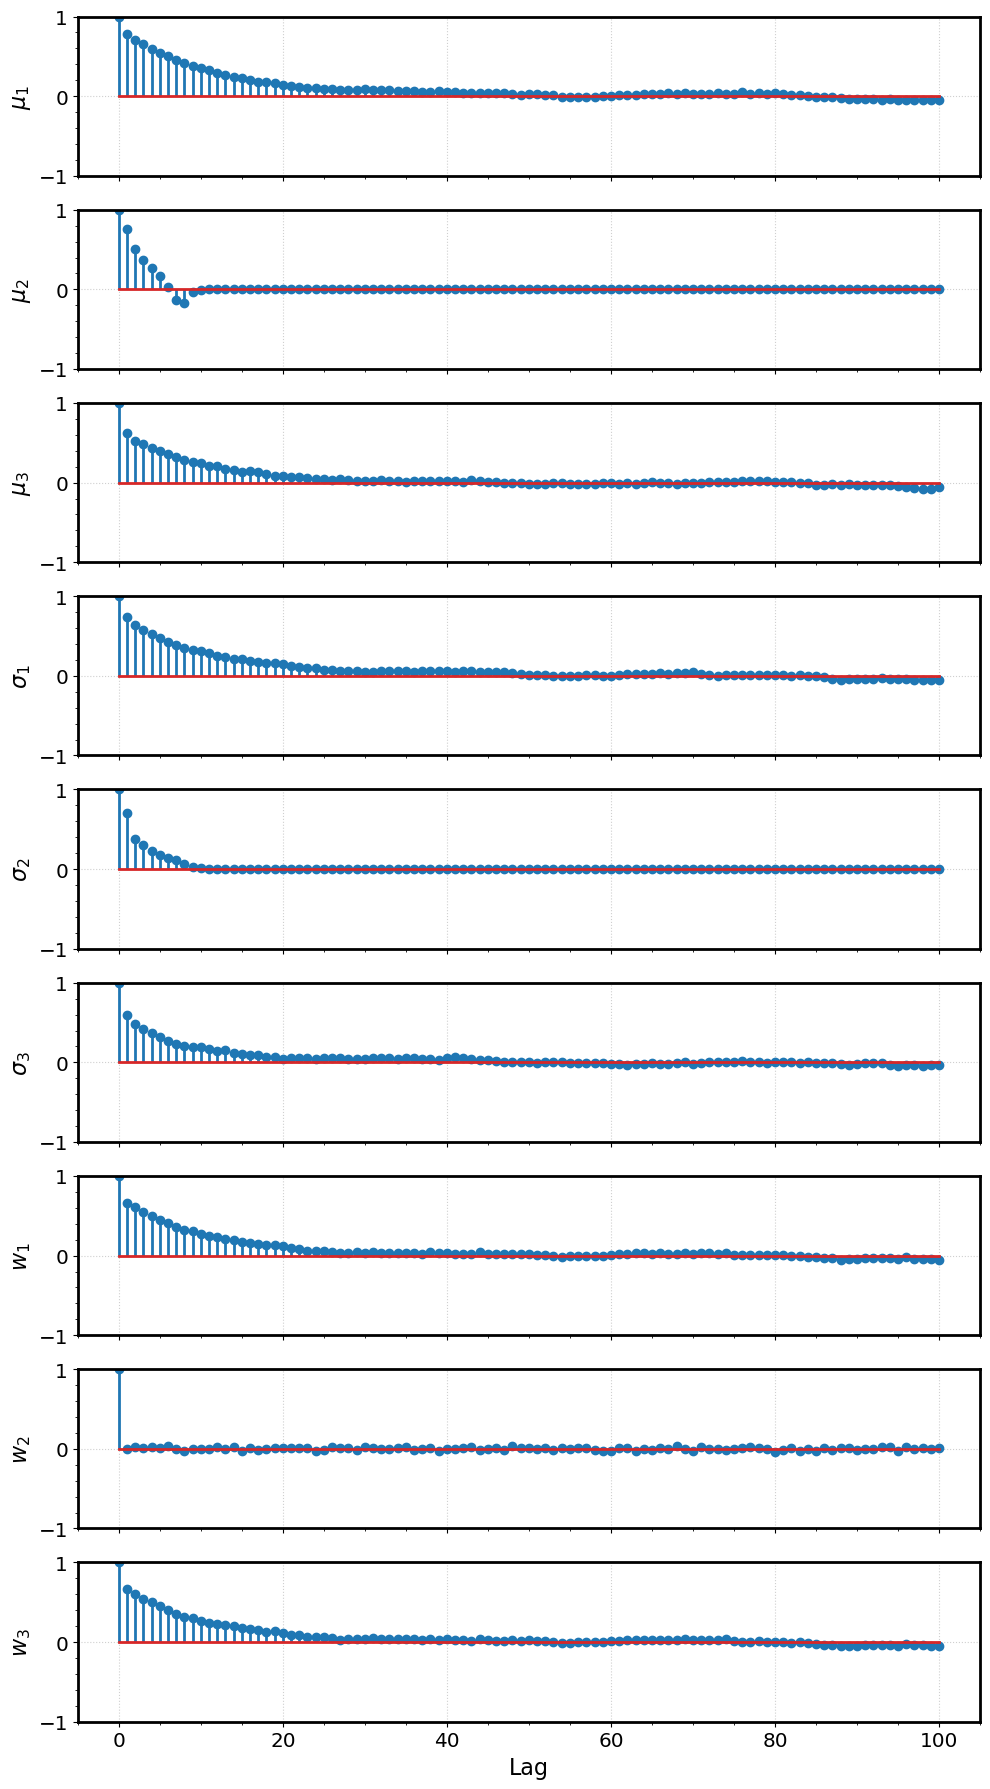

In [22]:
fig_acf, _ = autocorr_plot(samples_new, param_names=names, nlags=100)

In [23]:
thinning = 20
samples_new = samples_new[:, ::thinning]
samples_new.shape

(9, 170)

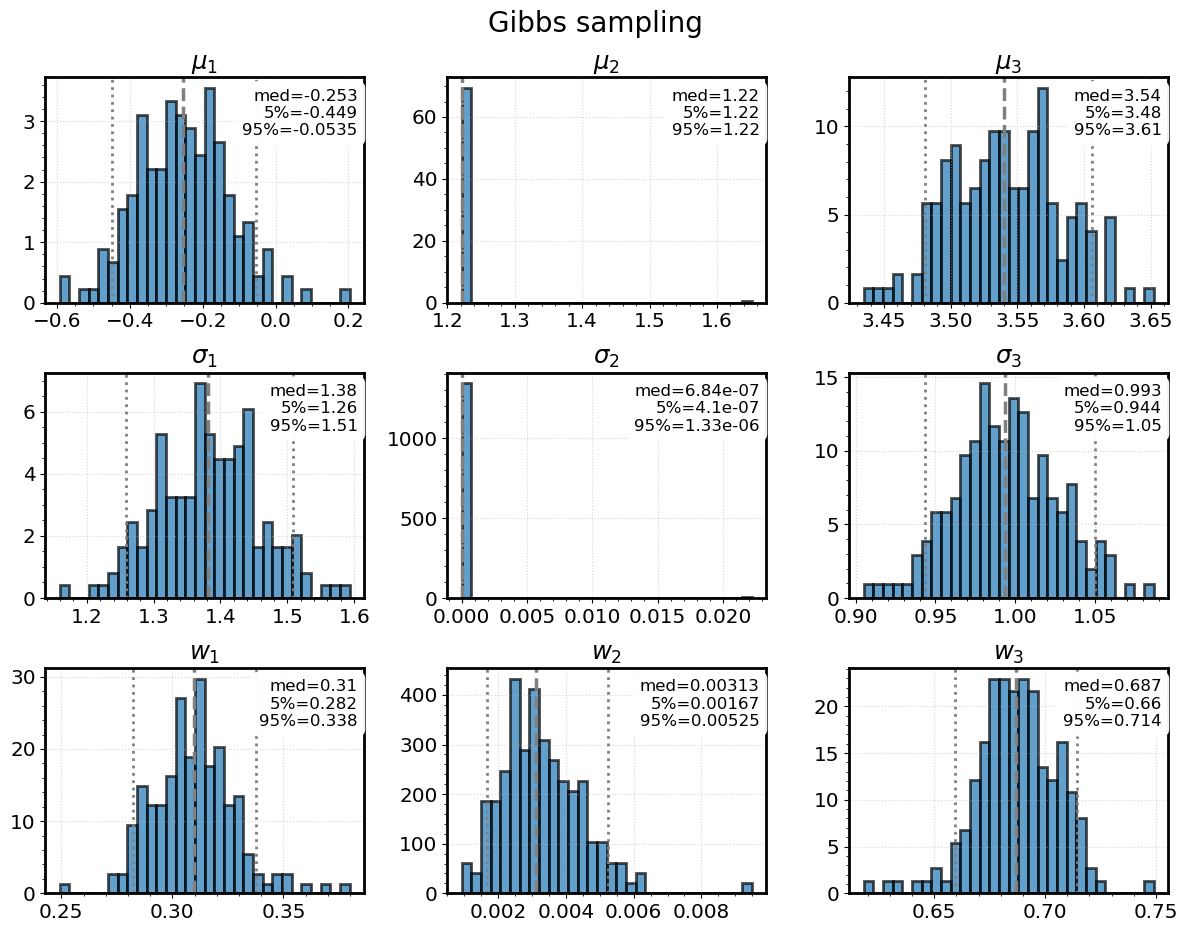

In [25]:
fig, axes = marginal_plots(samples_new, param_names=names, bins=30)#, true_values=true_vals_mean)
plt.savefig('../figure/gibbs_sampling/gibbs_sampling_clusters=3.png', dpi=300, bbox_inches='tight')
plt.savefig('../figure/gibbs_sampling/gibbs_sampling_clusters=3.pdf', dpi=300, bbox_inches='tight')
plt.show()